In [1]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.linear_model import LogisticRegression
from pygam import LogisticGAM
import pandas as pd

In [2]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [3]:
dat = pd.read_csv('breast-cancer-wisconsin.data', header=None, na_values='?')
dat.columns = [
  'id',#Sample code number            id number
  'thickness',#Clump Thickness               1 - 10
  'size_uniformity',#Uniformity of Cell Size       1 - 10
  'shape_uniformity',#Uniformity of Cell Shape      1 - 10
  'adhesion',#Marginal Adhesion             1 - 10
  'size',#Single Epithelial Cell Size   1 - 10
  'nuclei',#Bare Nuclei                   1 - 10
  'chromatin',#Bland Chromatin               1 - 10
  'nucleoli',#Normal Nucleoli               1 - 10
  'mitoses',#Mitoses                       1 - 10
  'class'#Class:            (2 for benign, 4 for malignant)
]
dat['class'] = np.where(dat['class']==4,1,0)
dat = dat.dropna(axis=0, how='any')
dat

,id,thickness,size_uniformity,shape_uniformity,adhesion,size,nuclei,chromatin,nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2.0,1,1,1,0
695,841769,2,1,1,1,2,1.0,1,1,1,0
696,888820,5,10,10,3,7,3.0,8,10,2,1
697,897471,4,8,6,4,3,4.0,10,6,1,1


In [4]:
X = dat.loc[:, 'thickness':'mitoses']
y = dat['class']

In [5]:
y.value_counts()

0    444
1    239
Name: class, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [7]:
#The sklearn version of logistic regression automatically has a ridge penalty
#Large C means small penalty here (opposite of lambda)
#Could also set penalty = 'none', but I wanted the comparison here.
lmfit = LogisticRegression(C=1000000).fit(X_train, y_train)

yhat_lm = lmfit.predict(X_test)
print(np.mean(y_test==yhat_lm))
np.mean(y_test!=yhat_lm)


0.9601769911504425


0.03982300884955752

In [8]:
lmfit.coef_

array([[ 0.49491974,  0.1291073 ,  0.49875363,  0.14286514, -0.14720946,
         0.3861488 ,  0.3272828 ,  0.29299472,  0.42899586]])

In [9]:
#What happens if we do some penalizing?
lmfit2 = LogisticRegression(C=1).fit(X_train, y_train)

yhat_lm2 = lmfit2.predict(X_test)
np.mean(y_test!=yhat_lm2)


0.03982300884955752

In [10]:
%%capture
#Maybe we could do better with an additive model
#I just did the (Bad) lazy thing of using the same lambda for all terms to keep it fast for class.  Don't be me.
fit = LogisticGAM().gridsearch(X_train.values, y_train, lam = np.logspace(-1, 5, 30))

100% (30 of 30) |########################| Elapsed Time: 0:00:05 Time:  0:00:05


In [11]:
fit.lam

[[529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708],
 [529.8316906283708]]

In [12]:
yhat_gam = fit.predict(X_test)
np.mean(y_test!=yhat_gam)

0.035398230088495575

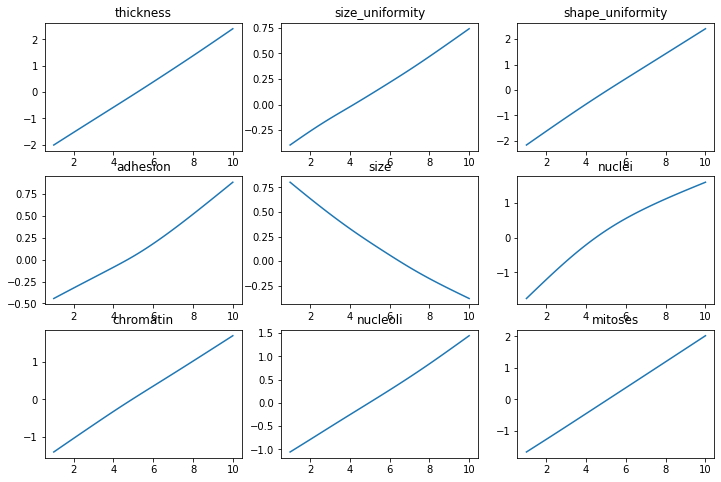

In [13]:
fig, axs = plt.subplots(3, 3)
titles = X_test.columns

for i, ax in enumerate(axs.ravel()):
    Xfake = fit.generate_X_grid(i)
    pdep, confi = fit.partial_dependence(term = i, X= Xfake, width=.95)

    ax.plot(Xfake[:, i], pdep)
    #ax.plot(XX[:, i], confi[0], c='r', ls='--')
    ax.set_title(titles[i])

plt.show()